This notebook only makes a figure out of pre-computed behavior predictions.
It relies on finding a summary file in the `results` folder.

To recompute ad reproduce these results from scratch, one would need to run the following scripts:
1. `./scripts/chewie/extract_data.py` to save the ground truth data
2. `./scripts/chewie/run_biRNN_decoder.py` to save the results of the biRNN decoder 
3. `./scripts/chewie/run_avg_per_epoch.py` to save the trial-average per-condition predictions
4. `./scripts/chewie/run_PSID.py` to save the results of the PSID decoder
5. `./scripts/chewie/run_CEBRA.py` to save the results of the CEBRA decoder
6. Run LFADS/BAND training, ablate controls, run `scripts/band_performance.py` afterwards to save each run to a summary table (see `./scripts/run_sequence.py` as an example of all actions and naming that automatically goes into summary)

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

from plot_helpers import get_trials2plot, get_random_trials2plot, class_accuracy

from lfads_torch.metrics import r2_score

from matplotlib import rcParams
cm = 1/2.54  # centimeters in inches

rcParams["figure.dpi"] = 300
rcParams["savefig.dpi"] = 300
rcParams["font.size"] = 7

# %load_ext nb_black

mkdir -p failed for path /afs/inf.ed.ac.uk/user/n/nkudryas/.config/matplotlib: [Errno 13] Permission denied: '/afs/inf.ed.ac.uk/user/n/nkudryas/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-yxknh6qd because there was an issue with the default path (/afs/inf.ed.ac.uk/user/n/nkudryas/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
path = '../../results/Chewie_CO_FF_2016-10-07.h5'
# path = '../../results/Mihili_CO_FF_2014-02-17.h5'
data = {}
with h5py.File(path, 'r') as f:
   for key in f.keys():
      data[key] = f[key][()]
data.keys()

dict_keys(['test_M1_MUA_birnn_pred', 'test_M1_band_100f_4c_pred', 'test_M1_band_10f_2c_pred', 'test_M1_band_10f_2c_sample1_pred', 'test_M1_band_10f_2c_sample2_pred', 'test_M1_band_10f_2c_sample3_pred', 'test_M1_band_10f_2c_sample4_pred', 'test_M1_band_12f_2c_pred', 'test_M1_band_12f_2c_sample1_pred', 'test_M1_band_12f_2c_sample2_pred', 'test_M1_band_12f_2c_sample3_pred', 'test_M1_band_12f_2c_sample4_pred', 'test_M1_band_14f_2c_pred', 'test_M1_band_14f_2c_sample1_pred', 'test_M1_band_14f_2c_sample2_pred', 'test_M1_band_14f_2c_sample3_pred', 'test_M1_band_14f_2c_sample4_pred', 'test_M1_band_16f_2c_pred', 'test_M1_band_16f_2c_sample1_pred', 'test_M1_band_16f_2c_sample2_pred', 'test_M1_band_16f_2c_sample3_pred', 'test_M1_band_16f_2c_sample4_pred', 'test_M1_band_32f_2c_pred', 'test_M1_band_32f_2c_sample1_pred', 'test_M1_band_32f_2c_sample2_pred', 'test_M1_band_4f_2c_pred', 'test_M1_band_4f_2c_sample1_pred', 'test_M1_band_4f_2c_sample2_pred', 'test_M1_band_64f_2c_pred', 'test_M1_band_64f_2c_

In [3]:
dset='train'
train_vel = data[f'{dset}_behavior'][:]
train_target_direction = data[f'{dset}_target_direction'][:]
train_epoch = data[f'{dset}_epoch'][:]

dset='valid'
vel = data[f'{dset}_behavior'][:]
target_direction = data[f'{dset}_target_direction'][:]
epoch = data[f'{dset}_epoch'][:]
pos = np.cumsum(vel, axis=1)

In [4]:
dir_index = np.array([
        sorted(set(target_direction)).index(i) for i in target_direction
    ])

train_dir_index = np.array([
        sorted(set(train_target_direction)).index(i) for i in train_target_direction
    ])

avg_vel_per_epoch = data['test_all_avg_per_epoch_pred']


In [5]:
np.random.seed(1)
# trials2plot = np.array([get_random_trials2plot(vel, avg_vel_per_epoch, dir_index, epoch, i) for i in range(3)]).sum(0)
trials2plot = np.array([get_random_trials2plot(dir_index, epoch, i) for i in range(3)]).sum(0)
trials2plot.sum()

24

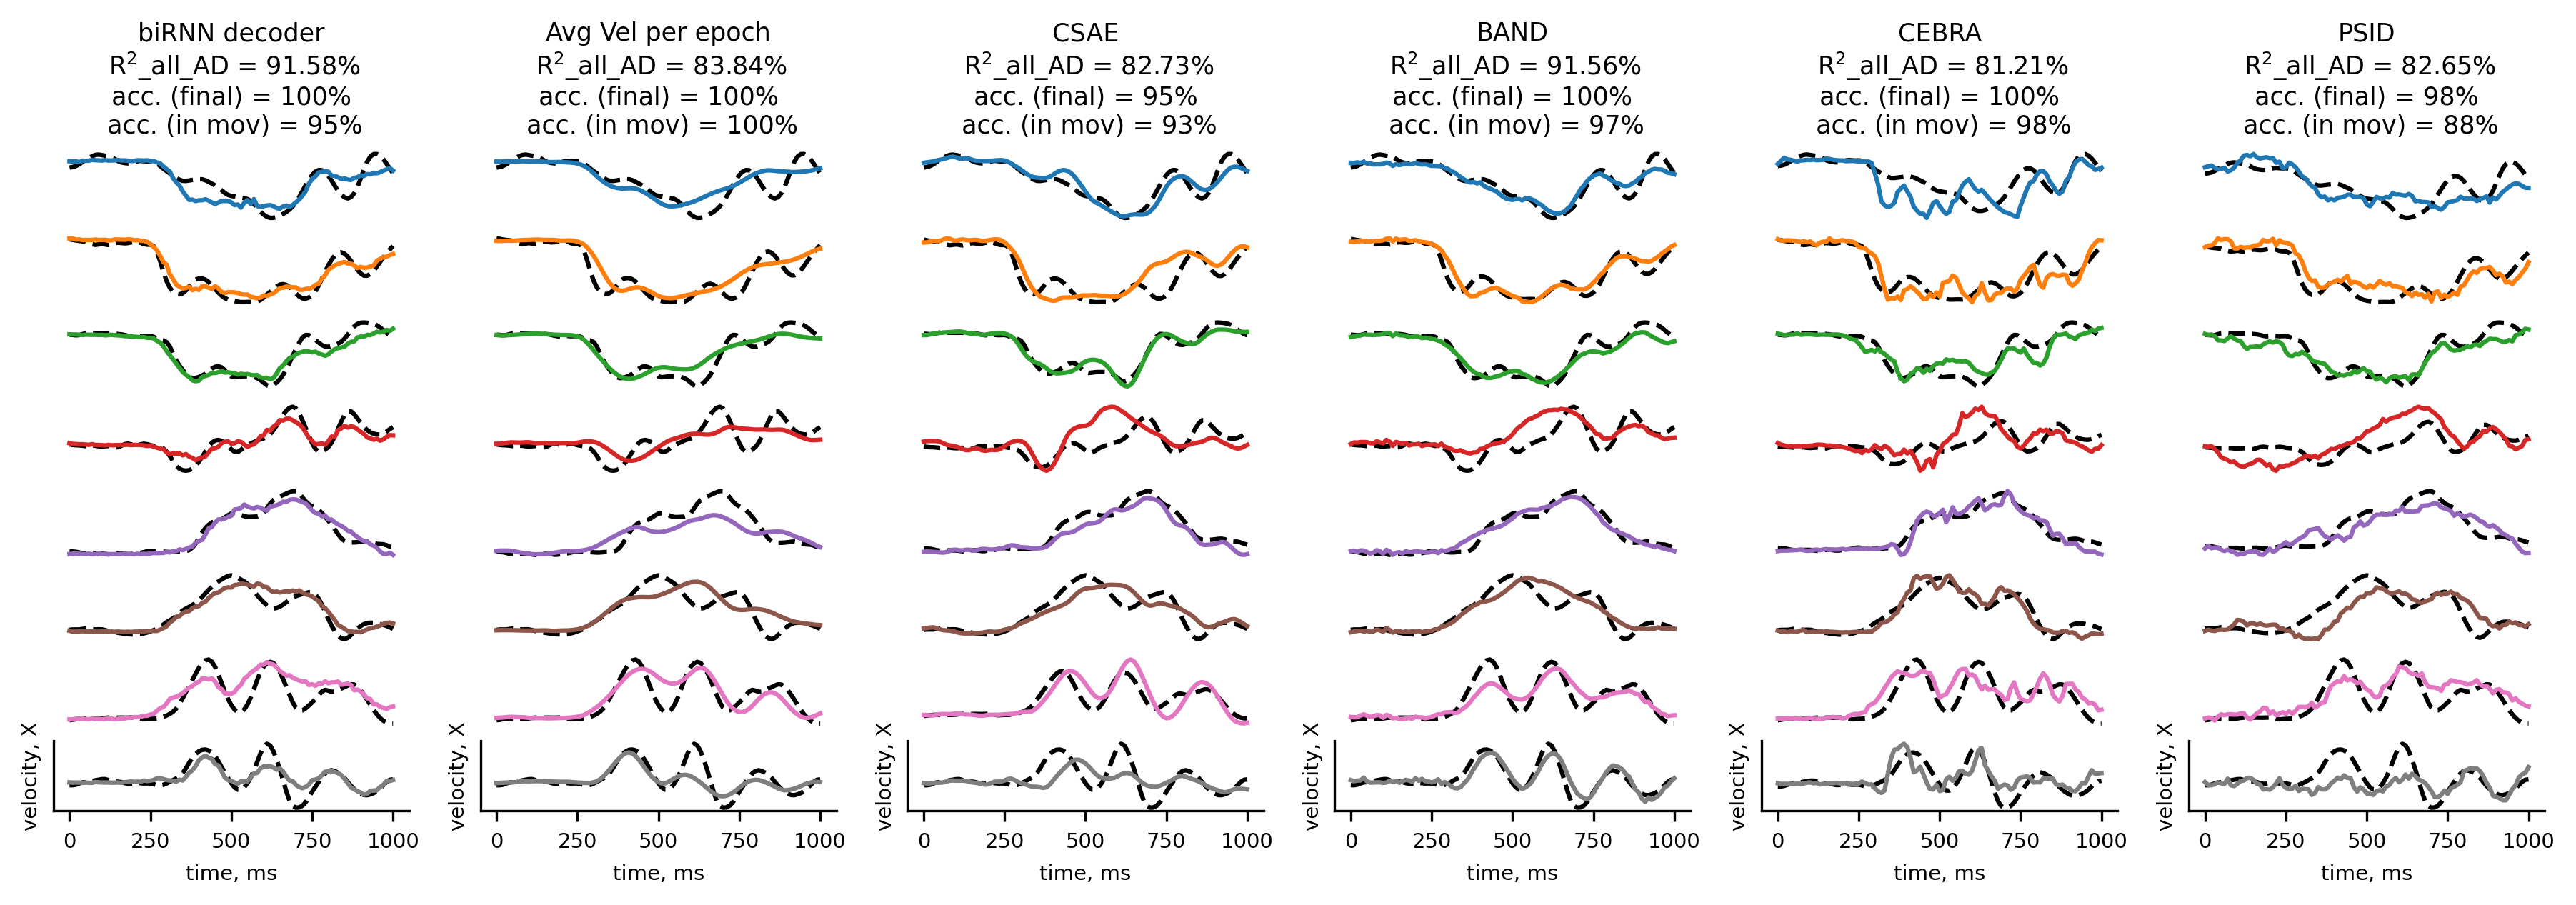

In [31]:
def plot_beh_pred(vel, pred_vel, dir_index, train_vel, train_dir_index, t2p, axes, area, epoch_name, component=0,title=""):
    '''
    Plot hand velocity and predicted hand velocity for each direction
    '''

    BIN_SIZE = 10 # ms
    time = np.arange(vel.shape[1]) * BIN_SIZE

    for v, ls in zip([vel, pred_vel], ["--", "solid"]):
        for t in range(0, vel.shape[0]):
            if t2p[t]:
                d = dir_index[t]
                axes[d].plot(
                    time,
                    v[t, :, component],
                    color=f"C{d}" if ls == "solid" else "k",
                    alpha=1,
                    ls=ls,
                )

    for ax in axes[:-1]:
        ax.axis("off")
    axes[-1].spines['top'].set_visible(False)
    axes[-1].spines['right'].set_visible(False)
    axes[-1].set_yticks([])
    axes[-1].set_xlabel("time, ms")
    axes[-1].set_ylabel("velocity, X")

    R2_iso_vel = r2_score(pred_vel,vel)
    # classify by final position
    class_acc_fp = class_accuracy(np.sum(train_vel,1), train_dir_index,
                                np.sum(pred_vel,1), dir_index)
    
    # classify by position at any given moment
    start_t = 50
    class_acc = class_accuracy(np.cumsum(train_vel,axis=1)[:,start_t:].reshape(-1,2), 
                               train_dir_index.reshape(1,-1).repeat(vel.shape[1]-start_t,0).T.reshape(-1),
                                np.cumsum(pred_vel,axis=1)[:,start_t:].reshape(-1,2), 
                                dir_index.reshape(1,-1).repeat(vel.shape[1]-start_t,0).T.reshape(-1))
    
    # # classify by velocity at any given moment
    # start_t = 25
    # class_acc = class_accuracy(train_vel[:,start_t:].reshape(-1,2), 
    #                            train_dir_index.reshape(1,-1).repeat(vel.shape[1]-start_t,0).T.reshape(-1),
    #                             pred_vel[:,start_t:].reshape(-1,2), 
    #                             dir_index.reshape(1,-1).repeat(vel.shape[1]-start_t,0).T.reshape(-1))
    
    axes[0].set_title(f'{title}\n R$^2$_{area}_{epoch_name} = {R2_iso_vel*100:.2f}% \n acc. (final) = {class_acc_fp*100:.0f}% \n acc. (in mov) = {class_acc*100:.0f}%')        

fig, axes = plt.subplots(8,6,figsize=(6*2.5, 8*.5))

# epoch_mask, epoch_name = (epoch==0), 'BL'
train_epoch_mask, epoch_mask, epoch_name = (train_epoch==1), (epoch==1), 'AD'
# epoch_mask, epoch_name = (epoch==epoch), 'all'
component = 0

area = 'all'
for i, (key, title) in enumerate(zip([f'test_{area}_birnn_pred','test_all_avg_per_epoch_pred',
                                      f'test_{area}_lfads_100f_4c_pred',f'test_{area}_band_100f_4c_pred',
                                      f'test_{area}_cebra_pred',f'test_{area}_psid_pred'],
                                  ['biRNN decoder', 'Avg Vel per epoch',
                                   'CSAE', 'BAND',
                                   'CEBRA',"PSID"])):

    plot_beh_pred(vel[epoch_mask], 
                data[key][epoch_mask], 
                dir_index[epoch_mask],
                train_vel[train_epoch_mask],
                train_dir_index[train_epoch_mask],
                trials2plot[epoch_mask], 
                axes[:,i], 
                area,
                epoch_name,
                component=1, 
                title=title)

fig.savefig("figs/Figure4")

Text(0.5, 1.0, 'Chewie_CO_FF_2016-10-07')

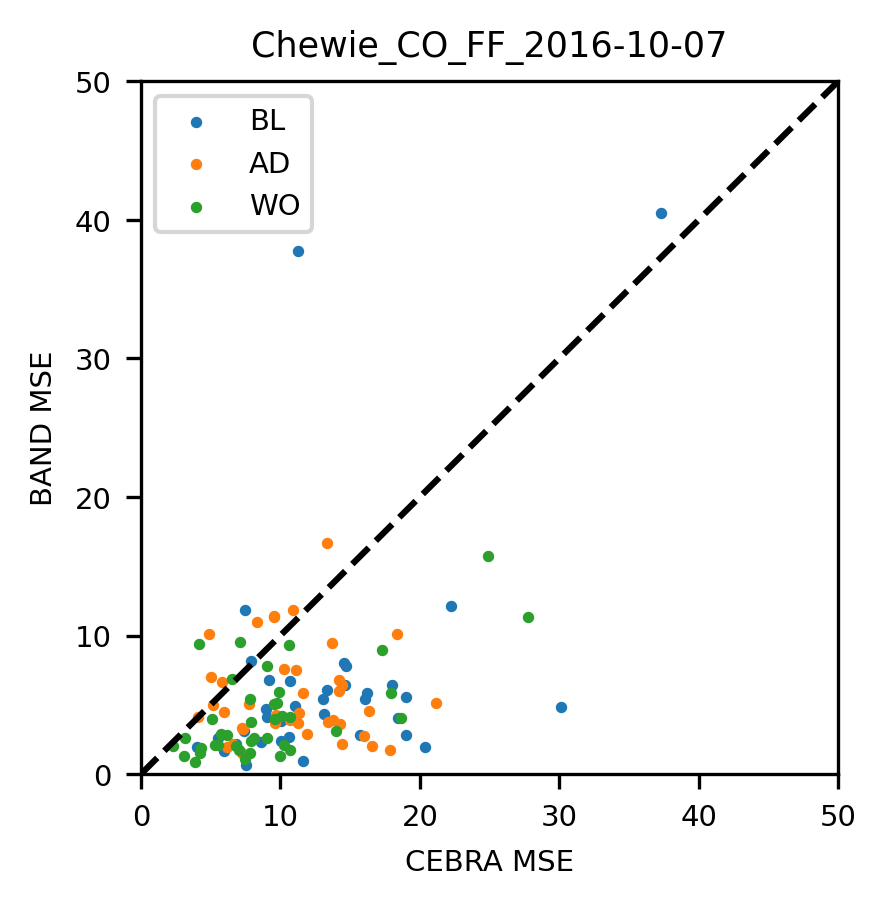

In [32]:
mse_cebra = np.mean((data[f'test_{area}_cebra_pred'] - vel) ** 2,-1).mean(-1)
mse_band = np.mean((data[f'test_{area}_band_pred'] - vel) ** 2,-1).mean(-1)
plt.figure(figsize=(3,3))
for e, en in enumerate(['BL','AD','WO']):
    mask = epoch==e
    plt.scatter(mse_cebra[mask], mse_band[mask],s=3,label=en)
plt.legend()
plt.xlim([0,50])
plt.ylim([0,50])
plt.plot([0,50],[0,50],'k--')
plt.xlabel('CEBRA MSE')
plt.ylabel('BAND MSE')
plt.title(path.split('/')[-1].split('.')[0])

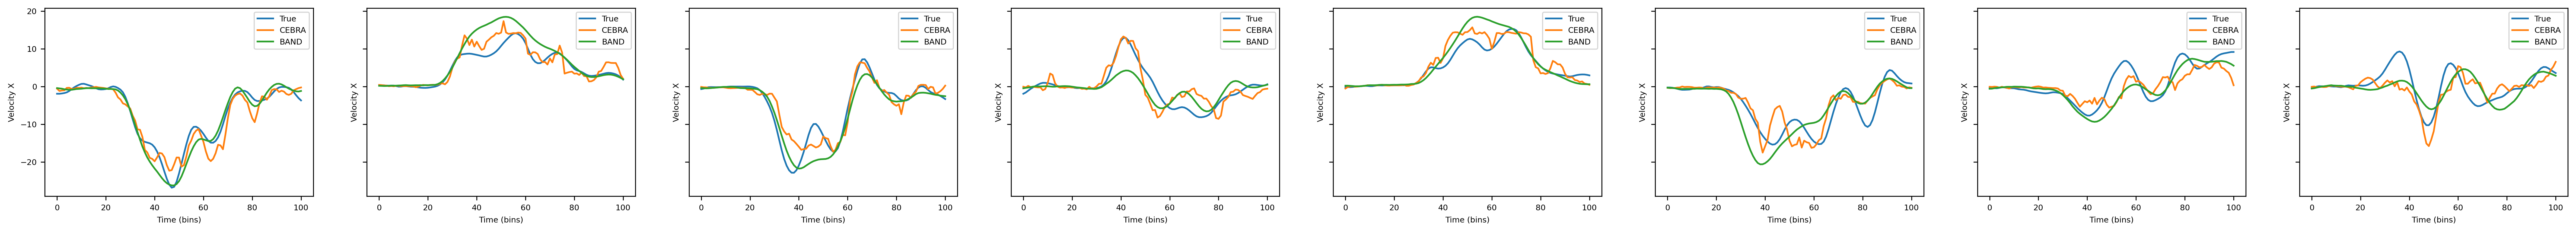

In [33]:
mask = (mse_band<20) & (mse_cebra<mse_band) & (epoch == 1)

fig, axes = plt.subplots(1,sum(mask),figsize=(sum(mask)*5, 3),sharey=True)
for i,m in enumerate(np.where(mask)[0]):
    axes[i].plot(vel[m,:,0].T,label='True')
    axes[i].plot(data[f'test_{area}_cebra_pred'][m,:,0].T,label='CEBRA')
    axes[i].plot(data[f'test_{area}_band_pred'][m,:,0].T,label='BAND')
    # axes[i].plot(data[f'test_{area}_birnn_pred'][m,:,0].T,label='biRNN')
    axes[i].legend()
    axes[i].set_xlabel('Time (bins)')
    axes[i].set_ylabel('Velocity X')

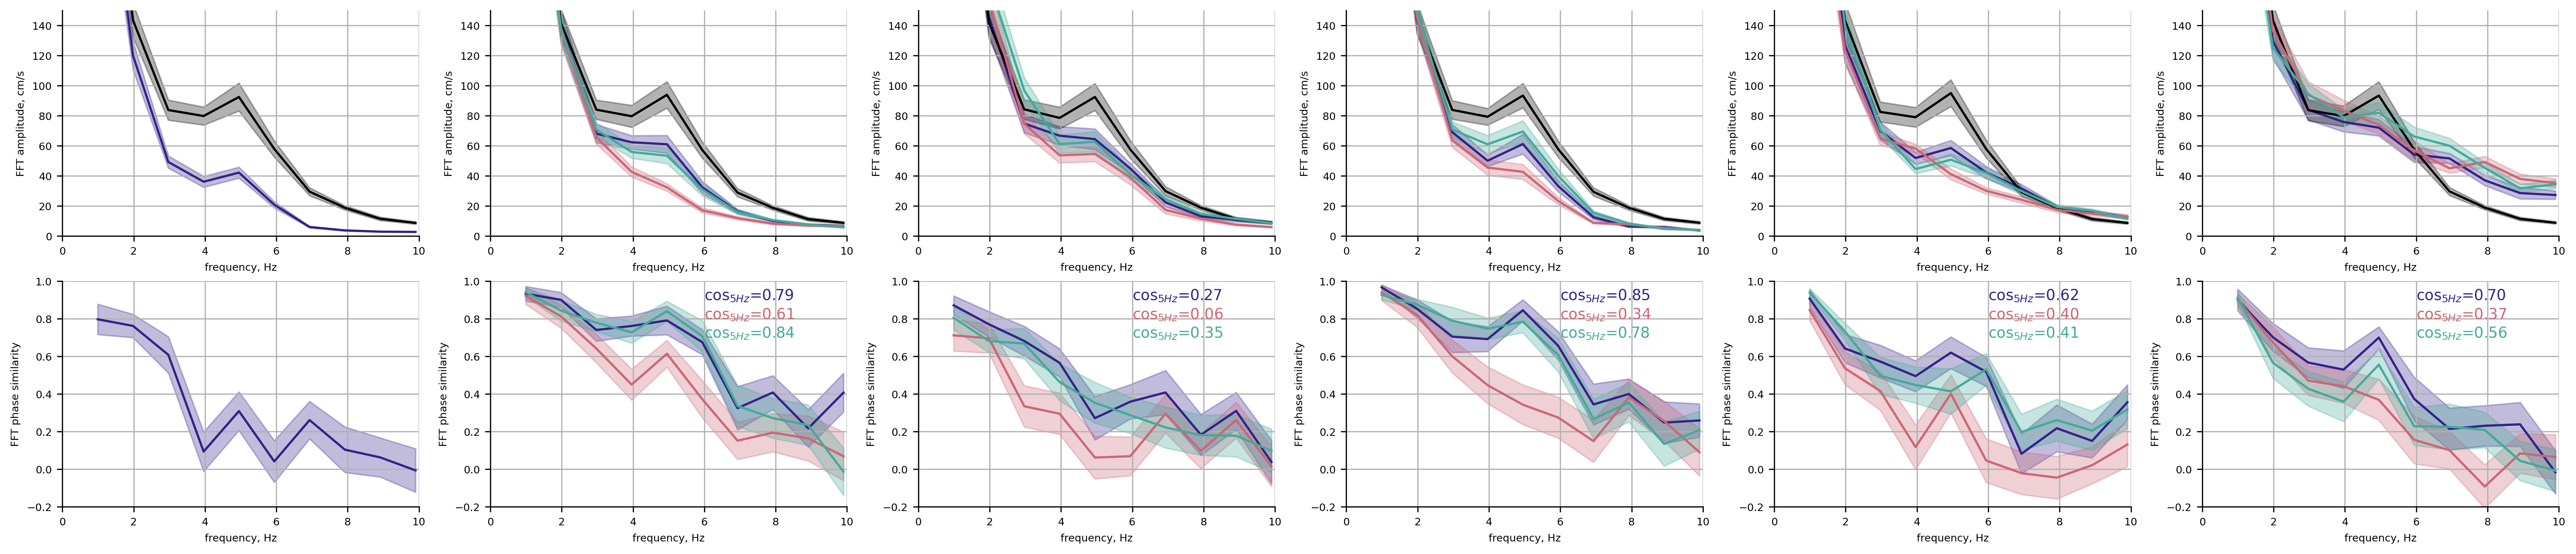

In [57]:
from scipy.fft import fft, fftfreq

def plot_fourier(ax, ax_p, V, V_true, dt=0.01, label='', 
                 c='k', linestyle='solid', peak_freq = 5,
                 text_pos = None):

        SR = []
        cos_sim = []
        for _ in range(100):

            idxs = np.random.choice(V.shape[0], V.shape[0], replace=True)

            x = V[idxs]
            xf = fft(x)  # Compute Fourier transform of x
            Sxx_all = (xf * xf.conj()).real # Compute power spectrum
            
            SR.append(np.sqrt(Sxx_all).mean(0))

            if V_true is not None:
                x_true = V_true[idxs]
                xf_true = fft(x_true)  # Compute Fourier transform of x_true
                cos = np.cos(np.angle(xf) - np.angle(xf_true))
                cos_sim.append(cos.mean(0))

        faxis = fftfreq(Sxx_all.shape[1]) / dt  # Construct frequency axis
        SR = np.asarray(SR) # [samples, freq]

        mask = (faxis > 0) & (faxis <= 10)
        ax.plot(
            faxis[mask],
            SR.mean(0)[mask],c=c, label=label, linestyle=linestyle)
        
        ax.fill_between(
            faxis[mask],
            SR.mean(0)[mask] - SR.std(0)[mask],
            SR.mean(0)[mask] + SR.std(0)[mask],
            alpha=0.3, color=c
        )

        ax.set_xlabel('frequency, Hz')
        ax.set_ylabel(r'FFT amplitude, cm/s')
        ax.set_ylim([0,150])
        ax.set_xlim([0,10])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True)

        if V_true is not None:
            cos_sim = np.asarray(cos_sim) # [samples, freq]

            ax_p.plot(
                faxis[mask],
                cos_sim.mean(0)[mask],c=c, label=label, linestyle=linestyle)
            
            ax_p.fill_between(
                faxis[mask],
                cos_sim.mean(0)[mask] - cos_sim.std(0)[mask],
                cos_sim.mean(0)[mask] + cos_sim.std(0)[mask],
                alpha=0.3, color=c
            )
            ax_p.set_xlabel('frequency, Hz')
            ax_p.set_ylabel(r'FFT phase similarity')
            ax_p.set_ylim([-0.2,1])
            ax_p.set_xlim([0,10])
            ax_p.spines['top'].set_visible(False)
            ax_p.spines['right'].set_visible(False)
            ax_p.grid(True)

            if text_pos is not None:
                idx_peak = np.argmin(np.abs(faxis - peak_freq))
                ax_p.text(text_pos[0], text_pos[1], 
                          r'cos$_{5Hz}$=' + f'{cos_sim.mean(0)[idx_peak]:.2f}', fontsize=10, color=c)

fig, axes = plt.subplots(2,6,figsize=(6*5, 6))

epoch_mask, epoch_name = (epoch==1), 'AD'
component = 0 # velocity X

# colors = {'all': 'C0', "PMd": 'C1', "M1": 'C2'}
colors = {'PMd': '#CC6677', 'M1': '#44AA99', 'all': '#332288'}
for i, key in enumerate(['test_all_avg_per_epoch_pred', 
                            lambda area: f'test_{area}_birnn_pred',
                            lambda area: f'test_{area}_lfads_100f_4c_pred',
                            lambda area: f'test_{area}_band_100f_4c_pred',
                            lambda area: f'test_{area}_psid_pred', 
                            lambda area: f'test_{area}_cebra_pred'],
                                ):
    for i_a, area in enumerate(['all','PMd', 'M1']):
        label = area
        if i==0:
            if area == 'all':
                plot_fourier(axes[0,i], axes[1,i],
                             data[key][epoch_mask][...,component], 
                             vel[epoch_mask][...,component],
                             dt=0.01, label='trial avg', c=colors[area])
        else:
            plot_fourier(axes[0,i], axes[1,i], 
                                        data[key(area)][epoch_mask][...,component], 
                                        vel[epoch_mask][...,component],
                         dt=0.01, label=label, c=colors[area],
                         text_pos = (6,0.9 - i_a*0.1))
        if area == 'all':
            plot_fourier(axes[0,i], axes[1,i], 
                                                            vel[epoch_mask][...,component], 
                                                            None,
                         dt=0.01, label='true velocity X', c='k')

In [66]:
def plot_beh_pred(vel, pred_vel, dir_index, t2p, axes, area, epoch_name, select = None, component=0,title=""):
    '''
    Plot hand velocity and predicted hand velocity for each direction
    '''
    BIN_SIZE = 10 # ms
    time = np.arange(vel.shape[1]) * BIN_SIZE

    for v, ls in zip([vel, pred_vel], ["--", "solid"]):
        for t in range(0, vel.shape[0]):
            if t2p[t]:
                d = dir_index[t]
                if select is None:
                    d_id = d
                else:
                    if d in select:
                        d_id = np.where(select == d)[0][0]
                    else: 
                        d_id = None
                if d_id is not None:
                    axes[d_id].plot(
                        time,
                        np.sum(v[t]**2,axis=-1)**0.5 if component == 'norm' else v[t, :, component],
                        color=f"C{d}" if ls == "solid" else "k",
                        alpha=1,
                        lw=1,
                    )
    for d in range(len(axes)):
        axes[d].axvline(0,c='k')

    for ax in axes[:-1]:
        ax.axis("off")
    axes[-1].spines['top'].set_visible(False)
    axes[-1].spines['right'].set_visible(False)
    axes[-1].set_yticks([])
    axes[-1].set_xlabel("time, ms")
    if component == 'norm':
        axes[-1].set_ylabel("velocity norm")
    else:
        component_names = ['velocity X', 'velocity Y']
        axes[-1].set_ylabel(component_names[component])
    axes[0].text(0,0,'Go Cue',rotation=90,va='top',ha='right')

    R2_iso_vel = r2_score(pred_vel,vel)
    # class_acc = 

    if title is not None:
        ttl = axes[0].set_title(fr'{title}: R$^2$ = {np.round(R2_iso_vel*100):.0f}%',loc='left')
        ttl.set_position([-.3, 1.1])


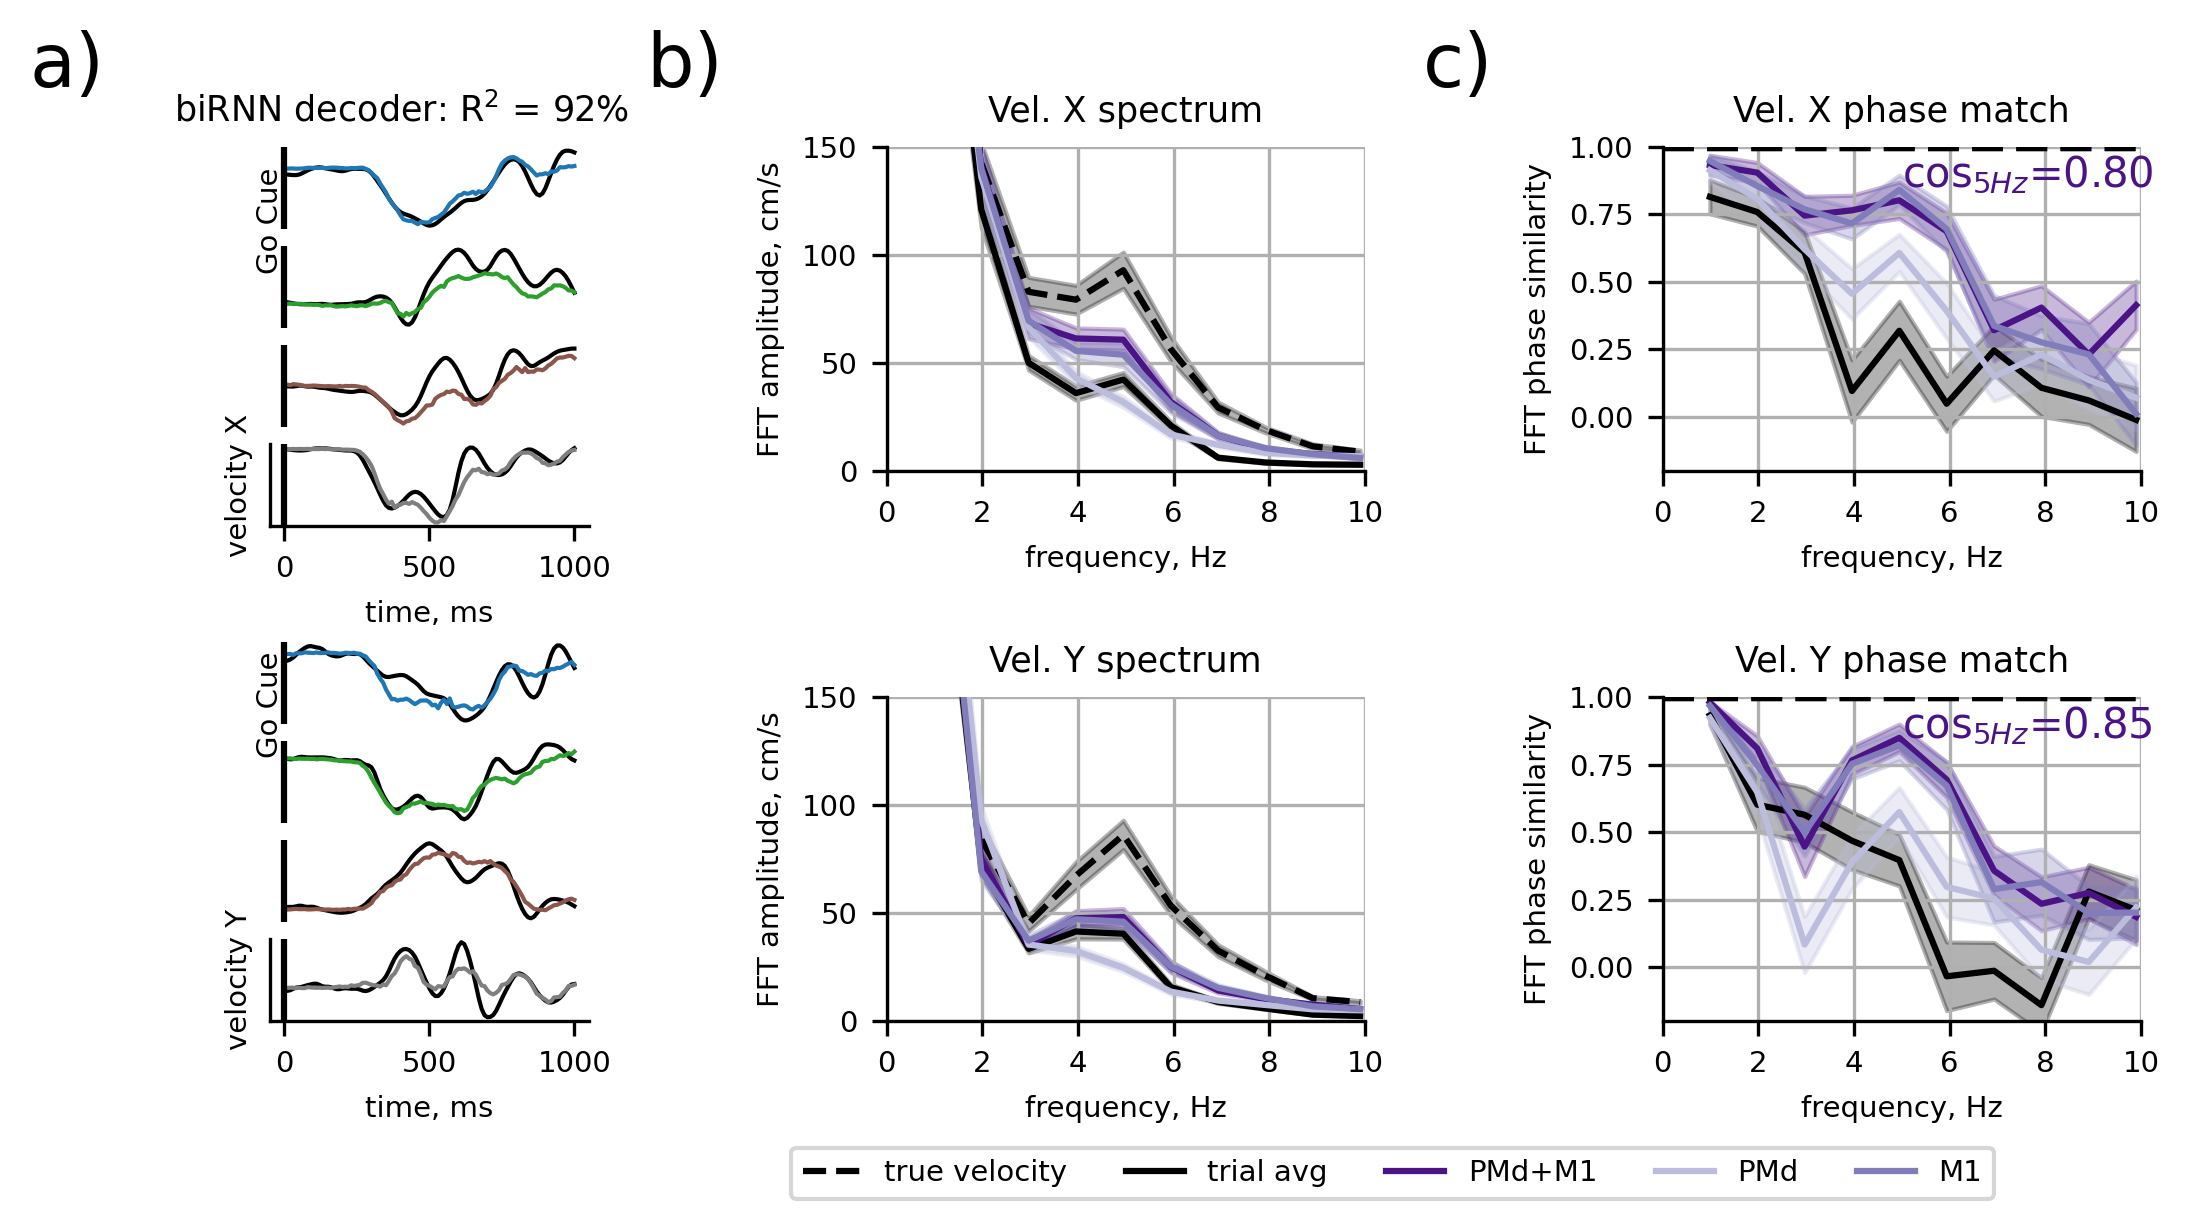

In [73]:
fig = plt.figure(figsize=(18*cm, 10*cm))

from goodman_panels import panels, panel_specs, label_panel, label_panels

layout = '''
abc
'''

axes = np.empty((4,6),dtype=object)
# blank = fig.add_subplot([0,0,1,1])
specs, gs = panel_specs(layout, fig=fig, gridspec_args={'left': 0.11, 'right': .99, 'bottom': 0.16, 'top': 0.9, 'hspace': 0.4, 'wspace': .7})
axes = {}

w_ratios = [2,3,3]
h_ratios = [1]
gs.set_width_ratios(w_ratios)
gs.set_height_ratios(h_ratios)

for letter in ['a']:
        subgs = specs[letter].subgridspec(9, 1)
        for j in range(9):
            axes[f"{letter}{j}"] = ax = fig.add_subplot(subgs[j])
        label_panel(axes[f"{letter}0"], letter, postfix=')')

for letter in ['b','c']:
        subgs = specs[letter].subgridspec(2, 1, hspace=0.7)
        for j in range(2):
            axes[f"{letter}{j}"] = ax = fig.add_subplot(subgs[j])
        label_panel(axes[f"{letter}0"], letter, postfix=')')


# epoch_mask, epoch_name = (epoch==0), 'BL'
epoch_mask, epoch_name = (epoch==1), 'AD'
# epoch_mask, epoch_name = (epoch==epoch), 'all'
area = 'all'
# colors = {'PMd': '#CC6677', 'M1': '#44AA99', 'all': '#332288'}
colors = {'PMd': '#BCBDDC', 'M1': '#807DBA', 'all': '#4A1486'}
model_key = lambda area: f'test_{area}_birnn_pred'

for component in [0,1]:
        title = 'biRNN decoder'
        ax = [axes[f'a{i+5*component}'] for i in range(4)]
        plot_beh_pred(vel[epoch_mask], 
                        data[model_key('all')][epoch_mask], 
                        dir_index[epoch_mask], 
                        trials2plot[epoch_mask], 
                        ax, 
                        area,
                        epoch_name,
                        select = np.array([0,2,5,7]),
                        component=component, 
                        title=title if component == 0 else None)
                
        for i_a, area in enumerate(['all','PMd', 'M1']):
                label = area
                component_name = 'X' if component == 0 else 'Y'
                if area == 'all':
                        label = 'PMd+M1'

                if area == 'all':
                        plot_fourier(axes[f'b{component}'], axes[f'c{component}'],
                                        vel[epoch_mask][...,component],
                                        None, 
                                        dt=0.01, label='true velocity', c='k', linestyle='--',)
                        plot_fourier(axes[f'b{component}'], axes[f'c{component}'],
                                        data['test_all_avg_per_epoch_pred'][epoch_mask][...,component],
                                        vel[epoch_mask][...,component],
                                        dt=0.01, label='trial avg', c='k')
                plot_fourier(axes[f'b{component}'], axes[f'c{component}'],
                                data[model_key(area)][epoch_mask][...,component],
                                vel[epoch_mask][...,component],
                                dt=0.01, label=label, c=colors[area],
                                text_pos = (5,0.85 - i_a*0.2) if area == 'all' else None)
                # horizontal legend
        axes['b0'].legend(loc=(-.2,-2.25),ncol=5)
        axes[f'b{component}'].set_title(f'Vel. {component_name} spectrum')
        axes[f'c{component}'].set_title(f'Vel. {component_name} phase match')
        axes['c0'].axhline(1,c='k',ls='--',lw=2)
        axes['c1'].axhline(1,c='k',ls='--',lw=2)
        # axes['c0'].set_xlabel('')
        # axes['d0'].set_xlabel('')


axes[f"a4"].set_visible(False)


fig.savefig("figs/Figure3.pdf")

In [60]:
for key in data.keys():
    if 'dpad' in key:
        print(key)

test_M1_dpad40A_pred
test_M1_dpad40Cz_pred
test_M1_dpad_pred
test_PMd_dpad40A_pred
test_PMd_dpad40Cz_pred
test_PMd_dpad_pred
test_all_dpad40A_pred
test_all_dpad40Cz_pred
test_all_dpad_pred
train_M1_dpad40A_pred
train_M1_dpad40Cz_pred
train_M1_dpad_pred
train_PMd_dpad40A_pred
train_PMd_dpad40Cz_pred
train_PMd_dpad_pred
train_all_dpad40A_pred
train_all_dpad40Cz_pred
train_all_dpad_pred


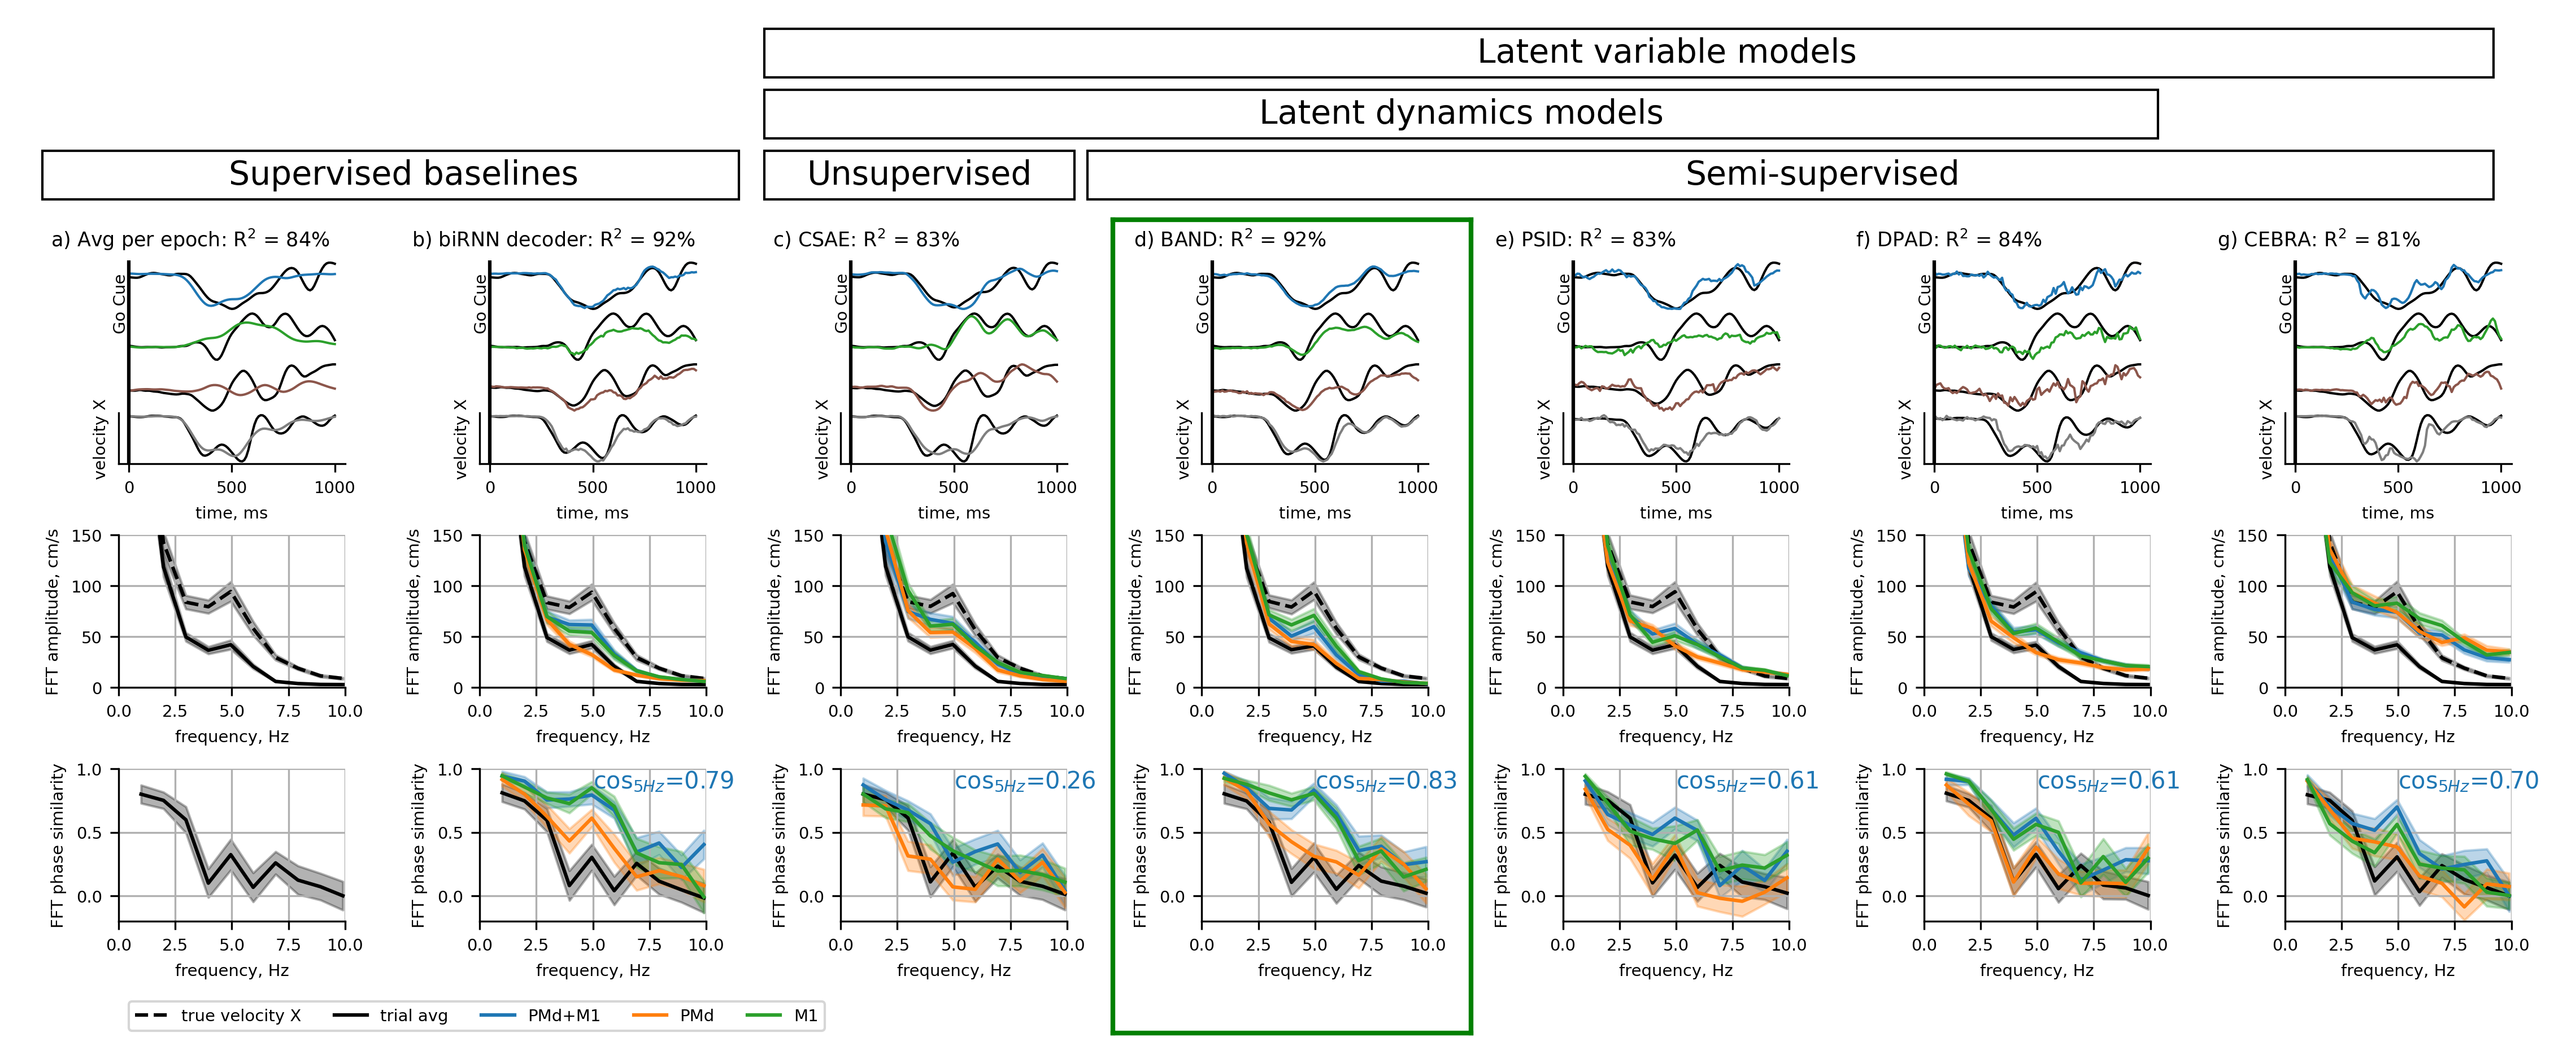

In [ ]:
fig = plt.figure(figsize=(15, 6))
# fig.add_axes([0,0,1,1])
axes = np.empty((4,7),dtype=object)
axes_fourier = np.empty(7,dtype=object)
axes_phase = np.empty(7,dtype=object)
mx = 0.02
my = 0.08
col_width = (1-mx) / 6.9

for j in range(7):
    for i in range(4):
        axes[i,j] = fig.add_axes([2*mx + j*col_width,
                                  .84-my-(i+1)/20,
                                  (1-mx)/11,
                                  1/20])
    axes_fourier[j] = fig.add_axes([2*mx + j*col_width,
                                    .92-my-5/20 - 0.25,
                                    (1-mx)/11,
                                    .15])
    
    axes_phase[j] = fig.add_axes([2*mx + j*col_width,
                                    .69-my-5/20 - 0.25,
                                    (1-mx)/11,
                                    .15])

band_highlight = fig.add_axes([0.25*mx+3*col_width,
                               0,
                               2*(1-mx)/18 + 1.6*mx,
                               .8])
band_highlight.set_xticks([])
band_highlight.set_yticks([])

titles = fig.add_axes([0,0.8,1,.2])
titles.axis('off')
# draw rectangles with text
fs = 14
lw = 1
# Decoding baselines | Latent variable models
titles.text(.5*mx + 4.5*col_width,.9,'Latent variable models',ha='center',va='top',fontsize=fs)
titles.add_patch(plt.Rectangle((0.5*mx+2*col_width,0.7),   5*col_width - 1.5*mx, 0.24, edgecolor='k', facecolor='none', lw=lw))
# - | Latent dynamics models | -
titles.text(0.*mx + 4*col_width,.6,'Latent dynamics models',ha='center',va='top',fontsize=fs)
titles.add_patch(plt.Rectangle((0.5*mx+2*col_width,0.4),   4*col_width - mx, 0.24, edgecolor='k', facecolor='none', lw=lw))
# Supervised | Unsupervised | Semi-supervised
titles.text(.5*mx + 1*col_width,.3,'Supervised baselines',ha='center',va='top',fontsize=fs)
titles.text(0.*mx + 2.5*col_width,.3,'Unsupervised',ha='center',va='top',fontsize=fs)
titles.text(0.*mx + 5*col_width,.3,'Semi-supervised',ha='center',va='top',fontsize=fs)
titles.add_patch(plt.Rectangle((0.5*mx+0.,0.1),            2*col_width - 0.5*mx, 0.24, edgecolor='k', facecolor='none', lw=lw))
titles.add_patch(plt.Rectangle((0.5*mx+2*col_width,0.1),   1*col_width - mx, 0.24, edgecolor='k', facecolor='none', lw=lw))
titles.add_patch(plt.Rectangle((-0.25*mx+3*col_width,0.1), 4*col_width - 0.75*mx, 0.24, edgecolor='k', facecolor='none', lw=lw))

# make spines green and bold
for spine in band_highlight.spines.values():
    spine.set_edgecolor('g')
    spine.set_linewidth(2)
#make face disappear
band_highlight.set_facecolor('none')

# epoch_mask, epoch_name = (epoch==0), 'BL'
epoch_mask, epoch_name = (epoch==1), 'AD'
# epoch_mask, epoch_name = (epoch==epoch), 'all'
component = 0 # velocity X

area = 'all'
for i, (key, title) in enumerate(zip(['test_all_avg_per_epoch_pred', f'test_{area}_birnn_pred',
                                      f'test_{area}_lfads_100f_4c_pred',f'test_{area}_band_100f_4c_pred',
                                      f'test_{area}_psid_pred', f'test_{area}_dpad40Cz_pred', f'test_{area}_cebra_pred'],
                                  ['a) Avg per epoch', 'b) biRNN decoder',
                                   'c) CSAE', 'd) BAND',
                                   'e) PSID', 'f) DPAD', 'g) CEBRA'])):
    plot_beh_pred(vel[epoch_mask], 
                data[key][epoch_mask], 
                dir_index[epoch_mask], 

                trials2plot[epoch_mask], 
                axes[:,i], 
                area,
                epoch_name,
                select = np.array([0,2,5,7]),
                component=component, 
                title=title)


colors = {'all': 'C0', "PMd": 'C1', "M1": 'C2'}
for i, key in enumerate(['test_all_avg_per_epoch_pred', 
                            lambda area: f'test_{area}_birnn_pred',
                            lambda area: f'test_{area}_lfads_100f_4c_pred',
                            lambda area: f'test_{area}_band_100f_4c_pred',
                            lambda area: f'test_{area}_psid_pred', 
                            lambda area: f'test_{area}_dpad40Cz_pred',
                            lambda area: f'test_{area}_cebra_pred'],
                                ):
    for i_a, area in enumerate(['all','PMd', 'M1']):
        label = area
        if area == 'all':
            label = 'PMd+M1'
        
        if area == 'all':
            plot_fourier(axes_fourier[i], axes_phase[i],
                         vel[epoch_mask][...,component],
                         None, 
                         dt=0.01, label='true velocity X', c='k', linestyle='--',)
            plot_fourier(axes_fourier[i], axes_phase[i], 
                         data['test_all_avg_per_epoch_pred'][epoch_mask][...,component], 
                         vel[epoch_mask][...,component],
                         dt=0.01, label='trial avg', c='k')
        if i!=0:
            plot_fourier(axes_fourier[i], axes_phase[i],
                         data[key(area)][epoch_mask][...,component], 
                         vel[epoch_mask][...,component],
                         dt=0.01, label=label, c=colors[area],
                         text_pos = (5,0.85 - i_a*0.2) if area == 'all' else None)
        if i == 1:
            # horizontal legend
            axes_fourier[i].legend(loc=(-1.55,-2.25),ncol=5)

fig.savefig("figs/SFigure3.pdf")